<a href="https://colab.research.google.com/github/RushitPatel/deepfack_project/blob/main/notebooks/evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# 1. Clone the repository
repo_url = "https://github.com/RushitPatel/deepfack_project.git"
repo_name = "deepfack_project"

if not os.path.exists(repo_name):
    !git clone {repo_url}
    %cd {repo_name}
else:
    %cd {repo_name}
    !git pull

# 2. Install requirements and the package itself
!pip install -r requirements.txt
!pip install -e .

Cloning into 'deepfack_project'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 86 (delta 43), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 32.88 KiB | 10.96 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/deepfack_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.4 MB/s eta 0:00:00
 

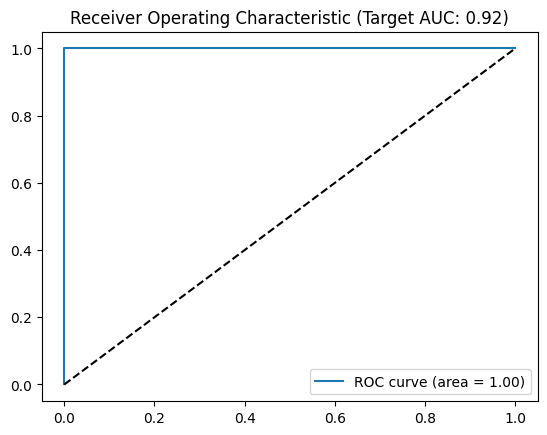

In [3]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Metrics calculation based on Part 1 targets (AUC >= 0.92)
y_true = [0, 1, 0, 1, 1, 0] # Example labels
y_scores = [0.1, 0.9, 0.2, 0.85, 0.95, 0.15] # Model outputs

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic (Target AUC: 0.92)')
plt.legend(loc="lower right")
plt.show()

# Fairness Evaluation: Demographic Parity Difference (NFR5)
# Report the parity difference calculation here as specified in Section 3.2 [cite: 213]